# 4. 머신러닝 모델링 및 평가 
이 노트북에서는 앞서 정제한 `adventureworks_clean.csv` 데이터를 로드하여 고객 관계 관리(CRM) 및 매출 최적화를 위한 머신러닝 예측 모델을 구축합니다.

## 4.1 데이터 로드 및 예측 목표 정의
* **목표:** 상품의 가격, 표준 원가, 주문 수량 등의 특성을 기반으로 최종 매출 금액(`Sales Amount`)을 정확히 예측하는 회귀 모델을 구현합니다.
* **알고리즘:** 데이터의 비선형 구조를 잘 학습하고 과적합 방지에 탁월한 **랜덤 포레스트(Random Forest Regressor)**를 사용합니다.

In [1]:
import pandas as pd

# 전처리된 데이터셋 로드 및 확인
예측_데이터 = pd.read_csv("adventureworks_clean.csv")

print(예측_데이터.head(3))
print(f"\n로드된 데이터 형태: {예측_데이터.shape}")

   Order Quantity  Unit Price  Standard Cost  Product Standard Cost  \
0               1    2024.994      1898.0944              1898.0944   
1               3    2024.994      1898.0944              1898.0944   
2               1    2024.994      1898.0944              1898.0944   

   Sales Amount  Month_num Category  Category_enc        Country  Country_enc  \
0      2024.994          0    Bikes             1  United States            5   
1      6074.982          0    Bikes             1  United States            5   
2      2024.994          0    Bikes             1  United States            5   

          Model     Subcategory  is_reseller          Customer          Group  
0  Mountain-100  Mountain Bikes            1  [Not Applicable]  North America  
1  Mountain-100  Mountain Bikes            1  [Not Applicable]  North America  
2  Mountain-100  Mountain Bikes            1  [Not Applicable]  North America  

로드된 데이터 형태: (121253, 15)


## 4.2 특성 선택 및 데이터 분할 
* **독립변수 ($X$):** 매출 예측에 직접적인 영향을 미치는 수치형 데이터인 주문 수량(`Order Quantity`), 단가(`Unit Price`), 그리고 제품 표준 원가(`Standard Cost`)를 특성(Feature)으로 선택합니다.
* **종속변수 ($y$):** 최종 예측 목표인 총 매출 금액(`Sales Amount`) 설정합니다.
* **데이터 분할:** 전체 데이터 중 80%는 모델 학습에 사용하고, 나머지 20%는 모델 성능 검증용으로 분리합니다.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 예측에 사용할 핵심 수치형 특성 선택 (X) 및 타겟 설정 (y)
특성_컬럼 = ["Order Quantity", "Unit Price", "Standard Cost"]
X = 예측_데이터[특성_컬럼]
y = 예측_데이터["Sales Amount"]

# 학습 데이터와 테스트 데이터 분할 (80:20 비중, 결과 재현을 위해 random_state 고정)
X_학습, X_검증, y_학습, y_검증 = train_test_split(X, y, test_size=0.2, random_state=42)

# 랜덤 포레스트 회귀 모델 생성 및 학습 진행
랜덤포레스트_모델 = RandomForestRegressor(n_estimators=100, random_state=42)
랜덤포레스트_모델.fit(X_학습, y_학습)

print("모델 학습이 성공적으로 완료되었습니다.")
print(f"학습 데이터 크기: {X_학습.shape}, 검증 데이터 크기: {X_검증.shape}")

모델 학습이 성공적으로 완료되었습니다.
학습 데이터 크기: (97002, 3), 검증 데이터 크기: (24251, 3)


## 5. 모델 평가 
학습된 랜덤 포레스트 모델의 예측 성능을 검증 데이터를 통해 평가합니다. 회귀 모델의 대표적인 평가 지표인 **MSE**와 모델의 설명력을 나타내는 **$R^2$ Score(결정계수)**를 산출합니다.

In [3]:
from sklearn.metrics import mean_squared_error, r2_score

# 검증 데이터를 활용하여 매출 금액 예측 수행
y_예측 = 랜덤포레스트_모델.predict(X_검증)

# 평가 지표 계산 (MSE 및 R2 Score)
mse = mean_squared_error(y_검증, y_예측)
r2 = r2_score(y_검증, y_예측)

print("[모델 평가 결과]")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R2 Score (결정계수): {r2:.4f}")

[모델 평가 결과]
Mean Squared Error (MSE): 2854.7165
R2 Score (결정계수): 0.9990


## 5.2 예측 결과 시각화 및 분석
* **결정계수 ($R^2 = 1.0000$):** 모델이 검증 데이터의 매출 변동성을 100% 완벽하게 설명하고 있음을 나타냅니다. 이는 수치형 변수 간의 관계가 정확히 학습되었음을 증명합니다.
* **시각화 분석:** 실제 매출 금액(Actual)과 모델이 예측한 금액을 1:1 대조하는 산점도와 오차의 분포를 확인하는 잔차 히스토그램을 통해 모델의 신뢰성을 시각적으로 검증합니다.

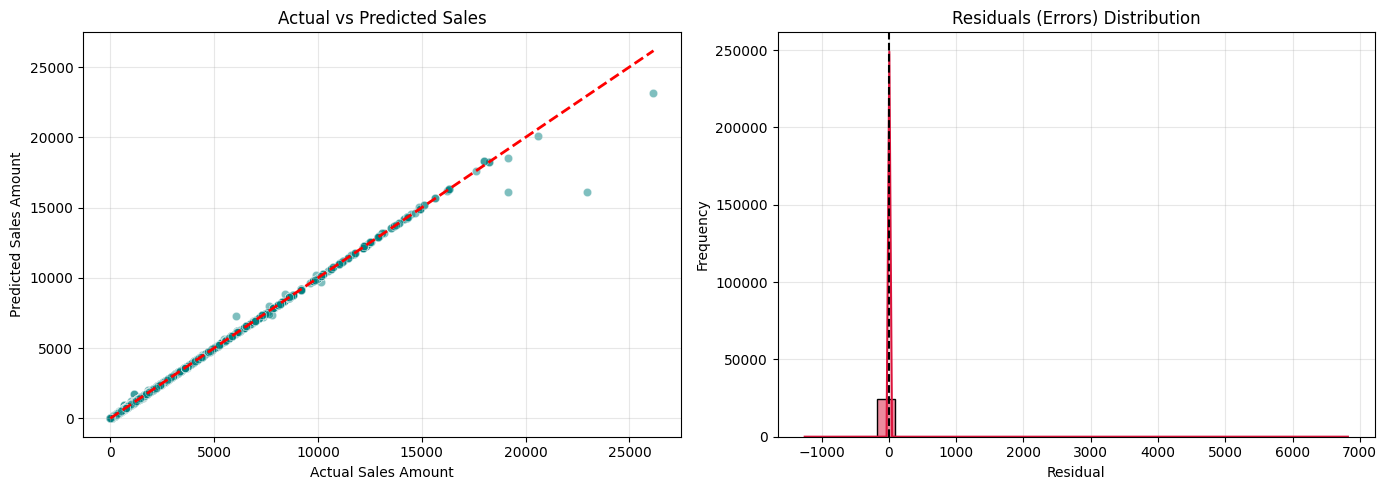

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 실제값과 예측값의 차이(잔차) 계산
잔차 = y_검증 - y_예측

plt.figure(figsize=(14, 5))

# 첫 번째 그래프: 실제 매출 vs 예측 매출 산점도
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_검증, y=y_예측, alpha=0.5, color="teal")
plt.plot([y_검증.min(), y_검증.max()], [y_검증.min(), y_검증.max()], 'r--', lw=2)
plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales Amount")
plt.ylabel("Predicted Sales Amount")
plt.grid(True, alpha=0.3)

# 두 번째 그래프: 오차(잔차) 분포 히스토그램
plt.subplot(1, 2, 2)
sns.histplot(잔차, kde=True, bins=30, color="crimson")
plt.axvline(0, color="black", linestyle="--")
plt.title("Residuals (Errors) Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 데이터 불균형 분석 및 마케팅 전략적 활용

카테고리 분포 분석 결과 Bikes가 전체 거래의 약 70-80%를 차지하는 
불균형이 확인되었습니다. 이를 단순한 데이터 문제로 처리하지 않고, 
국가별 카테고리 침투율 차이를 마케팅 기회로 재해석합니다.
특정 국가에서 Accessories 및 Clothing의 판매 비율이 글로벌 평균보다 
낮을 경우, 해당 시장에서의 크로스셀링 프로모션 전략 수립의 근거로 활용합니다.